In [1]:
from pathlib import Path # import from different source file location
import pandas as pd
import numpy as np
import warnings
from functools import reduce
from matplotlib import pyplot as plt # to plot data

# Last x months = test set; if test_size=0; model is fit on the whole available dataset
test_size = 18

# Input file location 


In [2]:
main_dir = Path.cwd()

inputs = {
    "Italy_10Y": "ita_10y.csv",       #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.IT.L.L40.CI.0000.EUR.N.Z
    "Germany_10Y": "ger_10y.csv",     #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.DE.L.L40.CI.0000.EUR.N.Z
    "Euribor_1M": "euribor1M.csv",    #https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.RT.MM.EURIBOR1MD_.HSTA
    "customer_rate": "rate_NMD.xlsx", #https://infostat.bancaditalia.it/inquiry/home?spyglass/taxo:CUBESET=/PUBBL_00/PUBBL_00_07/PUBBL_00_07_03/TDB20290&ITEMSELEZ=TDB20290_52000100:true&OPEN=false/&ep:LC=EN&COMM=BANKITALIA&ENV=LIVE&CTX=DIFF&IDX=2&/view:CUBEIDS=TFR30970_40099900
}

print(f"Please place the input files in this folder:\n{main_dir}")

#check for missing files
for series_name, file_name in inputs.items():
    file_path = main_dir / file_name

    if not file_path.exists():
        warnings.warn(f'Missing file: "{file_name}" in folder {main_dir}')
        

Please place the input files in this folder:
/Users/dima


## NMD rate data

In [3]:
rate_NMD = "rate_NMD.xlsx"
input_file = main_dir / rate_NMD

if not input_file.exists():
    print(f'Input file not found. Please place "{rate_NMD}" in: {main_dir}')
else:
    print(f'Found input file:\n{input_file}')


Found input file:
/Users/dima/rate_NMD.xlsx


In [4]:
rate = pd.read_excel(rate_NMD, sheet_name="Report")
rate = rate.dropna(axis=1, how="all")

rate = rate.rename(columns={rate.columns[0]: "DATE"})
rate["DATE"] = pd.to_datetime(rate["DATE"], dayfirst=True)

In [5]:
# Customer rates are reported quarterly -> convert to monthly data, then interpolate missing rates
# Create full monthly end-of-month date range
rate_start_date = rate["DATE"].min()
rate_end_date   = rate["DATE"].max()

monthly_dates = pd.date_range(
    start=rate_start_date,
    end=rate_end_date,
    freq=pd.offsets.MonthEnd()
)

# Reindex to monthly end-of-month dates
rate = (
    rate.set_index("DATE")
        .reindex(monthly_dates)
        .rename_axis("DATE")
        .reset_index()
)

# Linear interpolation of missing values
value_columns = [col for col in rate.columns if col != "DATE"]
rate[value_columns] = rate[value_columns].interpolate(method="linear")

## Market data 

In [6]:
#Read the market data
print(f"Please place the input files in this folder:\n{main_dir}")

inputs_market = {
    "Italy_10Y": "ita_10y.csv",       #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.IT.L.L40.CI.0000.EUR.N.Z
    "Germany_10Y": "ger_10y.csv",     #https://data.ecb.europa.eu/data/datasets/IRS/IRS.M.DE.L.L40.CI.0000.EUR.N.Z
    "Euribor_1M": "euribor1M.csv",    #https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.RT.MM.EURIBOR1MD_.HSTA
}

#User defined analysis period 
start_date = rate_start_date
end_date = rate_end_date

Please place the input files in this folder:
/Users/dima


In [7]:
#Merge the market data
tables = []

for series_name, file_name in inputs_market.items():
    file_path = main_dir / file_name

    if not file_path.exists():
        warnings.warn(f'Missing file: "{file_name}" in folder {main_dir}')
        continue

    df = pd.read_csv(file_path)

    # Drop columns containing "TIME PERIOD"
    df = df.loc[:, ~df.columns.str.contains(r"TIME[ _]PERIOD", case=False, na=False, regex=True)].copy()


    # Rename data column using dictionary key: Italy_10Y, Germany_10Y, Euribor_1M
    value_col = [col for col in df.columns if col != "DATE"][0]
    df = df.rename(columns={value_col: series_name})
    
    df["DATE"] = pd.to_datetime(df["DATE"])
    
    tables.append(df)

if not tables:
    raise FileNotFoundError("None of the input files were found.")

table = reduce(
    lambda left, right: pd.merge(left, right, on="DATE", how="outer"),
    tables
)

table["DATE"] = pd.to_datetime(table["DATE"])

table = table[
    (table["DATE"] >= start_date) &
    (table["DATE"] <= end_date)
]

table = table.sort_values("DATE").reset_index(drop=True)

# Dataset

In [8]:
rate = rate.rename(columns={"Producer households": "customer_rate"})

# Make sure both DATE columns are datetime
table["DATE"] = pd.to_datetime(table["DATE"])
rate["DATE"] = pd.to_datetime(rate["DATE"])

# Merge into a new table
input_table = pd.merge(
    table,
    rate,
    on="DATE",
    how="left"
)

input_table = input_table.sort_values("DATE").reset_index(drop=True)

input_table

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate
0,2010-06-30,4.10,2.54,0.446364,0.210000
1,2010-07-31,4.03,2.62,0.583318,0.213333
2,2010-08-31,3.80,2.35,0.639954,0.216667
3,2010-09-30,3.86,2.30,0.618136,0.220000
4,2010-10-31,3.80,2.35,0.784238,0.223333
...,...,...,...,...,...
182,2025-08-31,3.54,2.67,1.890000,0.163333
183,2025-09-30,3.56,2.69,1.897227,0.160000
184,2025-10-31,3.44,2.62,1.906261,0.160000
185,2025-11-30,3.46,2.66,1.905600,0.160000


In [9]:
# Check total nulls by column
null_check = input_table.isnull().sum()

print(null_check)

DATE             0
Italy_10Y        0
Germany_10Y      0
Euribor_1M       0
customer_rate    0
dtype: int64


In [10]:
# Compute Spread betwem Italian and German bonds
input_table["Spread"] = input_table["Italy_10Y"] - input_table["Germany_10Y"]

# Compute dummy indicating Covid period (feb 2020 - dec 2020)
mask_covid = ((input_table["DATE"] >= "2020-02-28 00:00:00") & (input_table["DATE"] <= "2020-12-31 00:00:00"))
input_table["dCovid"] = 0
input_table.loc[mask_covid, "dCovid"] = 1

In [11]:
input_table[input_table["dCovid"] == 1]

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate,Spread,dCovid
116,2020-02-29,0.96,-0.47,-0.473150,0.03,1.43,1
117,2020-03-31,1.55,-0.54,-0.477682,0.03,2.09,1
118,2020-04-30,1.80,-0.45,-0.428100,0.03,2.25,1
119,2020-05-31,1.76,-0.52,-0.464350,0.03,2.28,1
120,2020-06-30,1.46,-0.43,-0.492864,0.03,1.89,1
121,2020-07-31,1.20,-0.52,-0.508826,0.03,1.72,1
122,2020-08-31,1.03,-0.52,-0.517333,0.03,1.55,1
123,2020-09-30,0.98,-0.52,-0.521727,0.03,1.50,1
124,2020-10-31,0.77,-0.61,-0.538454,0.03,1.38,1
125,2020-11-30,0.66,-0.61,-0.541429,0.03,1.27,1


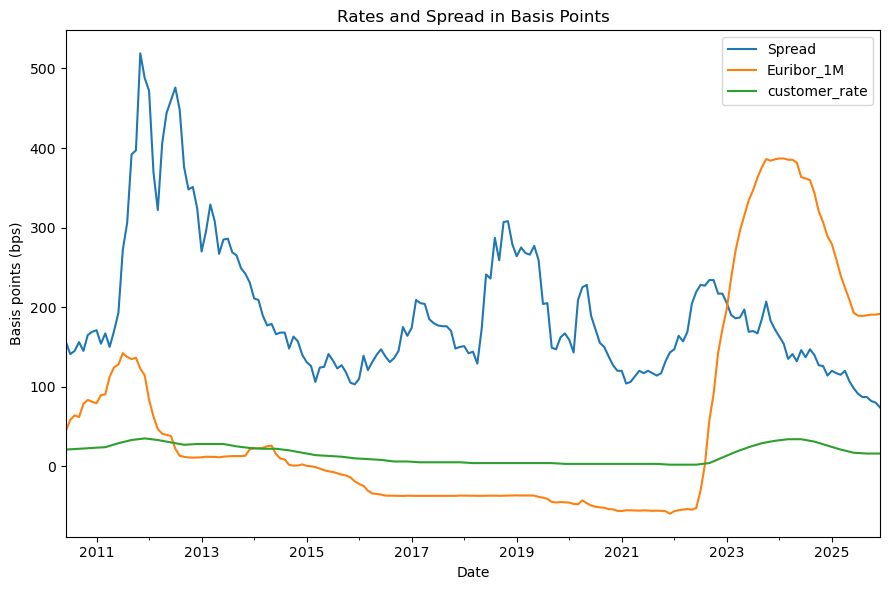

In [12]:
# Plot the data
plot_data = input_table.copy()

plot_data['Spread'] = plot_data['Spread'] * 100
plot_data['Euribor_1M'] = plot_data['Euribor_1M'] * 100
plot_data['customer_rate'] = plot_data['customer_rate'] * 100

ax = plot_data.plot(
    x='DATE',
    y=['Spread', 'Euribor_1M', 'customer_rate'],
    kind='line',
    figsize=(9, 6)
)

ax.set_ylabel('Basis points (bps)')
ax.set_xlabel('Date')
ax.set_title('Rates and Spread in Basis Points')
ax.grid(False)

plt.tight_layout()
plt.show()

### Perform ADF stationarity test on the IRs' series
The ADF tests for a presence of the unit root in a univariate process. 
There is a unit root if the variance of the process is not constant, which implies a presence of serial-correlation (series is not stationary).

H<sub>0</sub>: The time series is non-stationary (there is unit-root).

In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.compat import lzip 

names = ['t-statistic', 't-statistic p-value', 'lag', 'n_of_obs']

aDF_test = adfuller(input_table['customer_rate'], regression='n')

if aDF_test[1] < 0.05:
    print(
        f"p-value = {aDF_test[1]:.4f}. "
        f"At the 5% significance level, we reject the null hypothesis. "
        f"The series is stationary."
    )
else:
    print(
        f"p-value = {aDF_test[1]:.4f}. "
        f"At the 5% significance level, we do not reject the null hypothesis. "
        f"The series is non-stationary."
    )

lzip(names, aDF_test)

p-value = 0.0337. At the 5% significance level, we reject the null hypothesis. The series is stationary.


[('t-statistic', np.float64(-2.1065775564497806)),
 ('t-statistic p-value', np.float64(0.033706155841735995)),
 ('lag', 10),
 ('n_of_obs', 176)]

# Model estimation

In [14]:
import statsmodels.api as sm # to estimate OLS models
from IPython.display import Markdown, display
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.api as sms

## Long term model 

In [15]:
input_table[["Euribor_1M", "customer_rate", "Spread"]] = input_table[["Euribor_1M", "customer_rate", "Spread"]] / 100
input_table

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate,Spread,dCovid
0,2010-06-30,4.10,2.54,0.004464,0.002100,0.0156,0
1,2010-07-31,4.03,2.62,0.005833,0.002133,0.0141,0
2,2010-08-31,3.80,2.35,0.006400,0.002167,0.0145,0
3,2010-09-30,3.86,2.30,0.006181,0.002200,0.0156,0
4,2010-10-31,3.80,2.35,0.007842,0.002233,0.0145,0
...,...,...,...,...,...,...,...
182,2025-08-31,3.54,2.67,0.018900,0.001633,0.0087,0
183,2025-09-30,3.56,2.69,0.018972,0.001600,0.0087,0
184,2025-10-31,3.44,2.62,0.019063,0.001600,0.0082,0
185,2025-11-30,3.46,2.66,0.019056,0.001600,0.0080,0


In [16]:
#separate training and testing sets

input_table = input_table.sort_values("DATE").reset_index(drop=True)

#test_table = input_table.tail(test_size)

#train_table = input_table.iloc[:-test_size]

if test_size == 0:
    train_table = input_table.copy()
    test_table = input_table.iloc[0:0].copy()
else:
    train_table = input_table.iloc[:-test_size].copy()
    test_table = input_table.iloc[-test_size:].copy()

In [17]:
alpha = 0.05

target_col = "customer_rate"
const_col = "cons"

initial_regressors = [
    "Euribor_1M",
    "Spread",
    "dCovid",
    const_col
]

market_rate = [
    "Euribor_1M"
]

# Variables expected to have positive coefficients
positive_sign_regressors = [
    "Euribor_1M",  #increase in market rate will lead to an increase of deposit rate if the bank wishes to keep the customers
    "Spread"       #yield increase of the local gov. bonds will force the bank to increase the deposit rate if the bank wishes to keep the customers
]

In [18]:
df = train_table.copy()
df[const_col] = 1

active_regressors = initial_regressors.copy()

models = []
elimination_log = []

iteration = 1

In [19]:
#Backward elimination
while True:

    y = df[target_col]
    X = df[active_regressors]

    model = sm.OLS(y, X, missing="drop").fit()

    params = model.params.copy()
    pvalues = model.pvalues.copy()

    models.append({
        "iteration": iteration,
        "regressors": active_regressors.copy(),
        "model": model,
        "params": params,
        "pvalues": pvalues
    })

    # Variables that can be eliminated (preserve constant)
    deletable_regressors = [
        v for v in active_regressors
        if v != const_col
    ]

    # -----------------------------
    # 1. Check expected signs
    # -----------------------------
    sign_checked_vars = [
        v for v in positive_sign_regressors
        if v in deletable_regressors
    ]

    wrong_sign_vars = params.loc[sign_checked_vars][
        params.loc[sign_checked_vars] <= 0
    ]

    if len(wrong_sign_vars) > 0:
        # Eliminate the variable with the most negative coefficient
        eliminated_regressor = wrong_sign_vars.idxmin()

        elimination_log.append({
            "iteration": iteration,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": eliminated_regressor,
            "eliminated_coef": params.loc[eliminated_regressor],
            "eliminated_pvalue": pvalues.loc[eliminated_regressor],
            "motive": "Wrong expected sign: coefficient is not positive",
            "status": "Regressor eliminated"
        })

        active_regressors.remove(eliminated_regressor)
        iteration += 1
        continue

    # -----------------------------
    # 2. Check p-values
    # -----------------------------
    # Do not check the constant for deletion
    pvalues_for_check = (
        pvalues
        .drop(const_col, errors="ignore")
        .fillna(1.0)
    )

    # If only the constant remains, stop
    if len(pvalues_for_check) == 0:
        elimination_log.append({
            "iteration": iteration,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "motive": None,
            "status": "Final model: only constant remains"
        })
        break

    max_pvalue = pvalues_for_check.max()
    worst_regressor = pvalues_for_check.idxmax()

    if max_pvalue > alpha:
        eliminated_regressor = worst_regressor

        elimination_log.append({
            "iteration": iteration,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": eliminated_regressor,
            "eliminated_coef": params.loc[eliminated_regressor],
            "eliminated_pvalue": pvalues.loc[eliminated_regressor],
            "motive": "P-value above 5%",
            "status": "Regressor eliminated"
        })

        active_regressors.remove(eliminated_regressor)
        iteration += 1
        continue

    # -----------------------------
    # 3. Stop condition
    # -----------------------------
    elimination_log.append({
        "iteration": iteration,
        "regressors_in_model": active_regressors.copy(),
        "eliminated_regressor": None,
        "eliminated_coef": None,
        "eliminated_pvalue": None,
        "motive": None,
        "status": "Final model: all regressors significant, signs correct, constant preserved"
    })

    break

# -----------------------------
# Results
# -----------------------------
elimination_log_df = pd.DataFrame(elimination_log)

final_model = models[-1]["model"]
final_regressors = models[-1]["regressors"]

print("Final regressors:")
print(final_regressors)

print("\nElimination log:")
display(elimination_log_df)

print("\nFinal model summary:")
print(final_model.summary())

Final regressors:
['Euribor_1M', 'Spread', 'dCovid', 'cons']

Elimination log:


,iteration,regressors_in_model,eliminated_regressor,eliminated_coef,eliminated_pvalue,motive,status
0,1,"[Euribor_1M, Spread, dCovid, cons]",None,None,None,None,"Final model: all regressors significant, signs..."



Final model summary:
                            OLS Regression Results                            
Dep. Variable:          customer_rate   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     101.8
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           2.46e-37
Time:                        20:05:36   Log-Likelihood:                 996.89
No. Observations:                 169   AIC:                            -1986.
Df Residuals:                     165   BIC:                            -1973.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Euribor_1M     0.0589      0.0

In [20]:
# Results
elimination_log_df = pd.DataFrame(elimination_log)

final_model_long = models[-1]["model"] if len(models) > 0 else None
final_regressors_long = models[-1]["regressors"] if len(models) > 0 else []

print("Final regressors:")
print(final_regressors_long)

print("\nElimination log:")
display(elimination_log_df)

if final_model_long is not None:
    print("\nFinal model summary:")
    print(final_model_long.summary())

Final regressors:
['Euribor_1M', 'Spread', 'dCovid', 'cons']

Elimination log:


,iteration,regressors_in_model,eliminated_regressor,eliminated_coef,eliminated_pvalue,motive,status
0,1,"[Euribor_1M, Spread, dCovid, cons]",None,None,None,None,"Final model: all regressors significant, signs..."



Final model summary:
                            OLS Regression Results                            
Dep. Variable:          customer_rate   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     101.8
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           2.46e-37
Time:                        20:05:36   Log-Likelihood:                 996.89
No. Observations:                 169   AIC:                            -1986.
Df Residuals:                     165   BIC:                            -1973.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Euribor_1M     0.0589      0.0

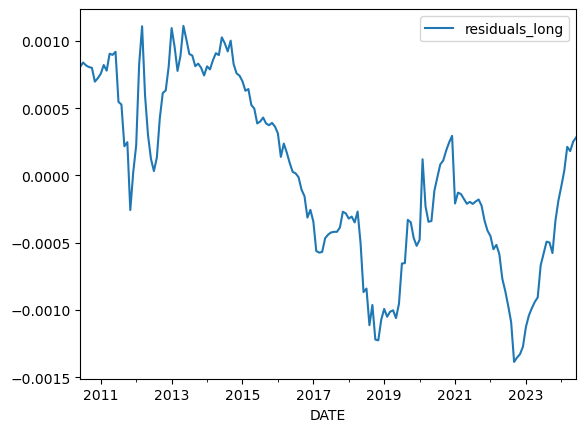

In [21]:
residuals_long=final_model_long.resid

train_table['residuals_long'] = residuals_long

train_table.plot(x='DATE', y=['residuals_long'], kind="line");

### Perform Durbin-Watson (DW) Test for no Autocorrelation

H<sub>0</sub>: There is no serial correlation in the residuals.

DW statistic is 2*(1-r), with r = sample (obsereved) autocorrelation of the residuals. The DW statistic is between 0 and 4:
- DW statistic = 2 -> no serial correlation.
- DW statistic = 0 -> evidence of positive serial correlation.
- DW statistic = 4 -> evidence of negative serial correlation.

There is no p-value of DW test. A widely accepted "normal" range of DW statistic is between 1.7 and 2.3.
Lower and upper bounds of DW statistic can be found here: https://real-statistics.com/statistics-tables/durbin-watson-table/

For n (sample size), k (# independent variables) and alpha=(0.01, 0.05):
- If DW statistic < lower bound -> first-order autocorrelation is present
- If DW statistic > upper bound -> autocorrelation not present (do not reject H<sub>0</sub>)
- If lower bound < DW statistic < upper bound -> test is inconclusive

In [22]:
display(Markdown(f"for the long term model, the n-sample size is: **{final_model_long.nobs}**, and k-independent variables are: **{final_model_long.df_model}** "))

for the long term model, the n-sample size is: **169.0**, and k-independent variables are: **3.0** 

In [23]:
DW=durbin_watson(residuals_long) # n=187, k=3 (alpha 5%)
print('DW statistics residuals_long = %.3f'%DW)
if (DW < 1.738):
    print('First-order autocorrelation is present \n')
elif (DW > 1.799):
    print('Residuals are not autocorrelated \n')
else:
    print('The test is inconclusive \n')

DW statistics residuals_long = 0.055
First-order autocorrelation is present 



### QQ plot of the residuals
If the residuals are approximately normally distributed, the points in the Q-Q plot should lie close to the 45-degree reference line.

Large deviations from the line, especially in the tails, suggest that the residuals may not be normally distributed.

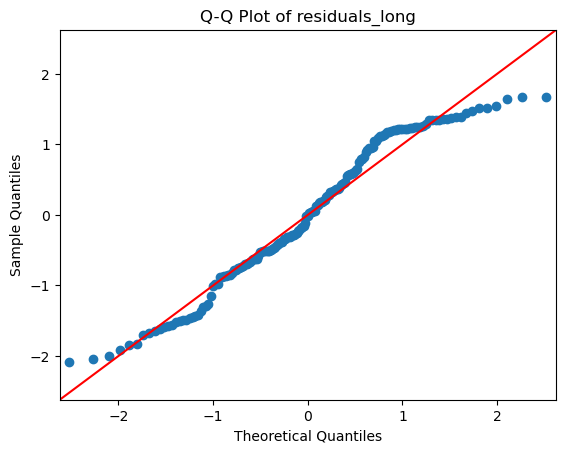

In [24]:
sm.qqplot(residuals_long, line='45', fit=True)

plt.title("Q-Q Plot of residuals_long")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()
#qq plot suggests residuals are not normal 

### Perform Breusch-Pagan (BP) Test for Homoskedasticity / Heteroskedasticity

H<sub>0</sub>: The residuals are homoskedastic, meaning the variance of the residuals is constant.

H<sub>A</sub>: The residuals are heteroskedastic, meaning the variance of the residuals is not constant.

The Breusch-Pagan (BP) test checks whether the variance of the regression residuals depends on the independent variables.

The BP test is based on an auxiliary regression of the squared residuals on the independent variables. If the independent variables help explain the squared residuals, this is evidence of heteroskedasticity.

The BP test reports:
- LM statistic: the Lagrange Multiplier test statistic.
- LM p-value: p-value for the LM statistic.
- F statistic: alternative test statistic based on the auxiliary regression.
- F p-value: p-value for the F statistic.

Decision rule for alpha = 0.05:
- If p-value < 0.05 -> reject H<sub>0</sub>; heteroskedasticity is present.
- If p-value >= 0.05 -> do not reject H<sub>0</sub>; there is not enough evidence of heteroskedasticity.

Interpretation:
- Small p-value -> evidence that residual variance is not constant.
- Large p-value -> no strong evidence that residual variance changes systematically with the independent variables.

In [25]:
names = ['Lagrange multiplier statistic', 'p-value',
        'f-value', 'f p-value']

BP = sms.het_breuschpagan(residuals_long, final_model_long.model.exog)
print(lzip(names, BP))

alpha = 0.05

bp_p_value = BP[1]
bp_f_p_value = BP[3]

if (bp_p_value < alpha) or (bp_f_p_value < alpha):
    print(
        f"Since either the BP p-value ({bp_p_value:.4f}) or the BP F p-value ({bp_f_p_value:.4f}) "
        f"is lower than 5%, we reject H0. Heteroskedasticity is present."
    )
else:
    print(
        f"Since both the BP p-value ({bp_p_value:.4f}) and the BP F p-value ({bp_f_p_value:.4f}) "
        f"are greater than or equal to 5%, we do not reject H0. There is no strong evidence of heteroskedasticity."
    )


[('Lagrange multiplier statistic', np.float64(16.961680427656784)), ('p-value', np.float64(0.0007196835623588181)), ('f-value', np.float64(6.135903278497053)), ('f p-value', np.float64(0.0005566653736019411))]
Since either the BP p-value (0.0007) or the BP F p-value (0.0006) is lower than 5%, we reject H0. Heteroskedasticity is present.


### Address heteroskedasticity of the residuals with HC1 estimator

In [26]:
HC_long = final_model_long.cov_HC1
print(HC_long)

[[ 1.34780371e-05 -4.73836596e-06  1.01695934e-07  4.59901735e-08]
 [-4.73836596e-06  2.07699762e-05 -3.06940501e-08 -3.38131227e-07]
 [ 1.01695934e-07 -3.06940501e-08  7.93971492e-09 -2.54389492e-09]
 [ 4.59901735e-08 -3.38131227e-07 -2.54389492e-09  8.36910188e-09]]


In [27]:
final_model_long.get_robustcov_results(cov_type = "HC1").summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.643     
Dependent Variable: customer_rate    AIC:                -1985.7748
Date:               2026-07-14 20:05 BIC:                -1973.2552
No. Observations:   169              Log-Likelihood:     996.89    
Df Model:           3                F-statistic:        224.9     
Df Residuals:       165              Prob (F-statistic): 4.67e-58  
R-squared:          0.649            Scale:              4.5118e-07
--------------------------------------------------------------------
                 Coef.   Std.Err.     t     P>|t|    [0.025   0.975]
--------------------------------------------------------------------
Euribor_1M       0.0589    0.0037  16.0375  0.0000   0.0516   0.0661
Spread           0.0534    0.0046  11.7079  0.0000   0.0444   0.0624
dCovid          -0.0005    0.0001  -5.6459  0.0000  -0.0007  -0.0003
cons             0.0002    0.0001   2.1698  0.0315   0.0000   0.0004
-------------------------------------------------------------------
Omnibus:               30.819        Durbin-Watson:           0.055
Prob(Omnibus):         0.000         Jarque-Bera (JB):        7.865
Skew:                  -0.137        Prob(JB):                0.020
Kurtosis:              1.980         Condition No.:           116  
===================================================================
Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

DW statistics residuals_long = 0.055
First-order autocorrelation is present 

[('Lagrange multiplier statistic', np.float64(16.961680427656784)), ('p-value', np.float64(0.0007196835623588181)), ('f-value', np.float64(6.135903278497053)), ('f p-value', np.float64(0.0005566653736019411))]
Since either the BP p-value (0.0007) or the BP F p-value (0.0006) is lower than 5%, we reject H0. Heteroskedasticity is present.


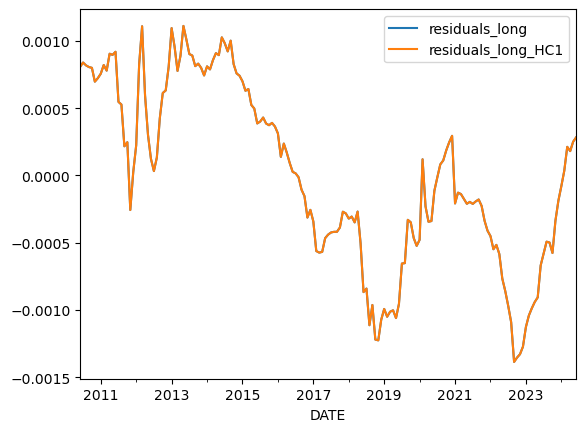

In [28]:
residuals_long_HC1=final_model_long.get_robustcov_results(cov_type = "HC1").resid
train_table['residuals_long_HC1'] = residuals_long_HC1
train_table.plot(x='DATE', y=['residuals_long', 'residuals_long_HC1'], kind="line");


#Durbin Watson
DW=durbin_watson(residuals_long) # n=187, k=3 (alpha 5%)
print('DW statistics residuals_long = %.3f'%DW)
if (DW < 1.738):
    print('First-order autocorrelation is present \n')
elif (DW > 1.799):
    print('Residuals are not autocorrelated \n')
else:
    print('The test is inconclusive \n')

# Breusch Pagan
BP = sms.het_breuschpagan(residuals_long_HC1, final_model_long.get_robustcov_results(cov_type = "HC1").model.exog)
print(lzip(names, BP))

alpha = 0.05

bp_p_value = BP[1]
bp_f_p_value = BP[3]

if (bp_p_value < alpha) or (bp_f_p_value < alpha):
    print(
        f"Since either the BP p-value ({bp_p_value:.4f}) or the BP F p-value ({bp_f_p_value:.4f}) "
        f"is lower than 5%, we reject H0. Heteroskedasticity is present."
    )
else:
    print(
        f"Since both the BP p-value ({bp_p_value:.4f}) and the BP F p-value ({bp_f_p_value:.4f}) "
        f"are greater than or equal to 5%, we do not reject H0. There is no strong evidence of heteroskedasticity."
    )


## Short term model 

$$
\Delta r_t = \theta (r_{t-1} - \hat{r}_{t-1}) 
+ \gamma^+ \Delta r_t^{m+} \mathbb{1}_{\mathbb R^+}(r_t^{m})  
+ \gamma^- \Delta r_t^{m-} \mathbb{1}_{\mathbb R^-}(r_t^{m})
\qquad \
$$ 

where:

- $\Delta r_t$ is the change in the customer rate.
- $\theta$ is the speed of adjustment toward the long-run equilibrium rate (stickiness effect). Theoretical range: $-1 \leq \theta \leq 0$, otherwise the error-correction mechanism is either explosive or going the wrong direction.
- $(r_{t-1} - \hat{r}_{t-1})$ residuals from the long-run relationship (error correction term).
- $\gamma^+ \leq \gamma^-$ measure the asymmetric convergence process; when rates fall (rise), bank should adjust NMD's rate faster (slower). $\gamma$ cannot be greater than $\beta$ from long term model: $\gamma \leq \beta$.
- $\Delta r_t^{m+}$ and $\Delta r_t^{m-}$ are positive and negative changes in the market rate.

### Condition to estimate short term model
if the beta coefficient (on market rate) from long model is not significant -> stop the fit of short model (long model is also not valid without significant beta)


In [29]:
missing_market_rates = [
    var for var in market_rate
    if var not in final_regressors_long
]

if len(missing_market_rates) == 0:
    print("ECM short term model valid")
else:
    print("long term market rate is not significant, ECM long and short models are not valid. Execution stopped")
    raise SystemExit

ECM short term model valid


### Define variables for short term 


In [30]:
#theta coefficient
lagged_residuals_theta = final_model_long.resid.values[:-1]

#delta customer rate
delta_customer_rate = train_table["customer_rate"].diff().values[1:]

#gamma coefficients
market_rate_series = train_table[market_rate]

delta_mkt_rate = market_rate_series.diff().iloc[1:]

delta_mkt_rate_pos = delta_mkt_rate.clip(lower=0)
delta_mkt_rate_neg = delta_mkt_rate.clip(upper=0)


def to_1d(x):
    return np.asarray(x).reshape(-1)
    
short_data = pd.DataFrame({
    "Y": to_1d(delta_customer_rate),
    "theta": to_1d(lagged_residuals_theta),
    "gamma": to_1d(delta_mkt_rate),
    "gamma_positive": to_1d(delta_mkt_rate_pos),
    "gamma_negative": to_1d(delta_mkt_rate_neg), 
}).dropna().reset_index(drop=True)

### Short term model estimation

| Equation type (step) | What's included | What it tests |
|---|---|---|
| $0$ | `gamma_positive` and `gamma_negative` individually | Full asymmetry: up-moves and down-moves have *different* coefficients |
| $1$ | Only `gamma_negative` | Partial asymmetry: only the "relevant" direction for the NMDs (liabilities) |
| $2$ | `gamma` — the full change, unsplit | Symmetry: up and down moves have the *same* coefficient |

In [31]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
alpha = 0.05

# beta = long-term pass-through coefficient
beta = float(final_model_long.params[market_rate[0]])

# --------------------------------------------------
# Helper
# --------------------------------------------------

def theta_signal(theta_value):
    if theta_value < -1:
        return "Warning: theta < -1"
    elif theta_value > 0:
        return "Warning: theta > 0"
    else:
        return "Theta valid: -1 <= theta <= 0"

# --------------------------------------------------
# Build short-term data
# --------------------------------------------------

Y_short = short_data["Y"]

# --------------------------------------------------
# Storage
# --------------------------------------------------
models_short = []
short_elimination_log = []

step = 0
iteration = 1

final_model_short = None
final_regressors_short = None

# --------------------------------------------------
# Main loop
# --------------------------------------------------
while True:

    # --------------------------------------------------
    # Define X according to current step
    # --------------------------------------------------
    if step == 0:
        active_regressors = [
            "theta",
            "gamma_positive",
            "gamma_negative"
        ]

    elif step == 1:
        active_regressors = [
            "theta",
            "gamma_negative"
        ]

    elif step == 2:
        active_regressors = [
            "theta",
            "gamma"
        ]

    else:
        active_regressors = [
            "theta"
        ]

    X_short = short_data[active_regressors]

    model_short = sm.OLS(Y_short, X_short).fit()

    params = model_short.params.copy()
    pvalues = model_short.pvalues.copy()

    theta_check = theta_signal(params["theta"])

    models_short.append({
        "iteration": iteration,
        "step": step,
        "regressors": active_regressors.copy(),
        "model": model_short,
        "params": params,
        "pvalues": pvalues,
        "theta_signal": theta_check
    })

    # --------------------------------------------------
    # Always check p-values first
    # theta is mandatory, so we only eliminate gamma terms
    # --------------------------------------------------
    deletable_regressors = [
        v for v in active_regressors
        if v != "theta"
    ]

    if len(deletable_regressors) > 0:

        pvalues_for_check = (
            pvalues
            .loc[deletable_regressors]
            .fillna(1.0)
        )

        max_pvalue = pvalues_for_check.max()

        if max_pvalue > alpha:

            eliminated_regressor = pvalues_for_check.idxmax()

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": eliminated_regressor,
                "eliminated_coef": params.loc[eliminated_regressor],
                "eliminated_pvalue": pvalues.loc[eliminated_regressor],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "P-value above 5%",
                "status": "Regressor eliminated"
            })

            # Move to the next valid model structure
            if step == 0:
                if eliminated_regressor == "gamma_positive":
                    step = 1
                else:
                    step = 2

            elif step == 1:
                step = 2

            elif step == 2:
                step = 3

            iteration += 1
            continue

    # --------------------------------------------------
    # Signal theta condition
    # --------------------------------------------------
    if theta_check != "Theta valid: -1 <= theta <= 0":
        short_elimination_log.append({
            "iteration": iteration,
            "step": step,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "theta_coef": params.loc["theta"],
            "theta_pvalue": pvalues.loc["theta"],
            "theta_signal": theta_check,
            "motive": "Theta outside valid ECM range",
            "status": "Warning only"
        })

    # --------------------------------------------------
    # Step-specific coefficient rules
    # --------------------------------------------------

    # -----------------------------
    # Step 0:
    # theta + gamma_positive + gamma_negative
    # -----------------------------
    if step == 0:

        gamma_pos = params["gamma_positive"]
        gamma_neg = params["gamma_negative"]

        # Rule: if gamma_negative < gamma_positive,
        # exclude gamma_positive and go to step 1
        if gamma_neg < gamma_pos:

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": "gamma_positive",
                "eliminated_coef": gamma_pos,
                "eliminated_pvalue": pvalues.loc["gamma_positive"],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "gamma_negative < gamma_positive",
                "status": "Regressor eliminated; move to step 1"
            })

            step = 1
            iteration += 1
            continue

        # Final beta restriction for this valid step:
        # exclude any gamma > beta
        if gamma_pos > beta:

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": "gamma_positive",
                "eliminated_coef": gamma_pos,
                "eliminated_pvalue": pvalues.loc["gamma_positive"],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "gamma_positive > beta",
                "status": "Regressor eliminated; move to step 1"
            })

            step = 1
            iteration += 1
            continue

        if gamma_neg > beta:

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": "gamma_negative",
                "eliminated_coef": gamma_neg,
                "eliminated_pvalue": pvalues.loc["gamma_negative"],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "gamma_negative > beta",
                "status": "Regressor eliminated; move to step 2"
            })

            step = 2
            iteration += 1
            continue

        final_model_short = model_short
        final_regressors_short = active_regressors.copy()

        short_elimination_log.append({
            "iteration": iteration,
            "step": step,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "theta_coef": params.loc["theta"],
            "theta_pvalue": pvalues.loc["theta"],
            "theta_signal": theta_check,
            "motive": None,
            "status": "Final model: gamma_positive and gamma_negative valid"
        })

        break

    # -----------------------------
    # Step 1:
    # theta + gamma_negative
    # -----------------------------
    elif step == 1:

        gamma_neg = params["gamma_negative"]

        # Rule: if gamma_negative > beta,
        # exclude it and go to step 2
        if gamma_neg > beta:

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": "gamma_negative",
                "eliminated_coef": gamma_neg,
                "eliminated_pvalue": pvalues.loc["gamma_negative"],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "gamma_negative > beta",
                "status": "Regressor eliminated; move to step 2"
            })

            step = 2
            iteration += 1
            continue

        final_model_short = model_short
        final_regressors_short = active_regressors.copy()

        short_elimination_log.append({
            "iteration": iteration,
            "step": step,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "theta_coef": params.loc["theta"],
            "theta_pvalue": pvalues.loc["theta"],
            "theta_signal": theta_check,
            "motive": None,
            "status": "Final model: only gamma_negative valid"
        })

        break

    # -----------------------------
    # Step 2:
    # theta + gamma
    # -----------------------------
    elif step == 2:

        gamma = params["gamma"]

        # Rule: if gamma > beta, exclude it
        if gamma > beta:

            short_elimination_log.append({
                "iteration": iteration,
                "step": step,
                "regressors_in_model": active_regressors.copy(),
                "eliminated_regressor": "gamma",
                "eliminated_coef": gamma,
                "eliminated_pvalue": pvalues.loc["gamma"],
                "theta_coef": params.loc["theta"],
                "theta_pvalue": pvalues.loc["theta"],
                "theta_signal": theta_check,
                "motive": "gamma > beta",
                "status": "Regressor eliminated; no valid gamma remains"
            })

            step = 3
            iteration += 1
            continue

        final_model_short = model_short
        final_regressors_short = active_regressors.copy()

        short_elimination_log.append({
            "iteration": iteration,
            "step": step,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "theta_coef": params.loc["theta"],
            "theta_pvalue": pvalues.loc["theta"],
            "theta_signal": theta_check,
            "motive": None,
            "status": "Final model: gamma valid"
        })

        break

    # -----------------------------
    # Step 3:
    # theta only
    # -----------------------------
    else:

        final_model_short = model_short
        final_regressors_short = active_regressors.copy()

        short_elimination_log.append({
            "iteration": iteration,
            "step": step,
            "regressors_in_model": active_regressors.copy(),
            "eliminated_regressor": None,
            "eliminated_coef": None,
            "eliminated_pvalue": None,
            "theta_coef": params.loc["theta"],
            "theta_pvalue": pvalues.loc["theta"],
            "theta_signal": theta_check,
            "motive": None,
            "status": "No valid gamma remains; theta-only model"
        })

        break

# --------------------------------------------------
# Results
# --------------------------------------------------
short_elimination_log_df = pd.DataFrame(short_elimination_log)

print("Final short-term regressors:")
print(final_regressors_short)

print("\nShort-term elimination log:")
display(short_elimination_log_df)

print("\nFinal short-term model summary:")
print(final_model_short.summary())

Final short-term regressors:
['theta', 'gamma']

Short-term elimination log:


,iteration,step,regressors_in_model,eliminated_regressor,eliminated_coef,eliminated_pvalue,theta_coef,theta_pvalue,theta_signal,motive,status
0,1,0,"[theta, gamma_positive, gamma_negative]",gamma_positive,0.048920,4.889462e-21,-0.020769,2.395698e-03,Theta valid: -1 <= theta <= 0,gamma_negative < gamma_positive,Regressor eliminated; move to step 1
1,2,1,"[theta, gamma_negative]",gamma_negative,0.015776,2.231810e-01,-0.045947,1.011543e-07,Theta valid: -1 <= theta <= 0,P-value above 5%,Regressor eliminated
2,3,2,"[theta, gamma]",None,NaN,NaN,-0.020771,2.805120e-03,Theta valid: -1 <= theta <= 0,None,Final model: gamma valid



Final short-term model summary:
                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.499
Model:                            OLS   Adj. R-squared (uncentered):              0.493
Method:                 Least Squares   F-statistic:                              82.81
Date:                Tue, 14 Jul 2026   Prob (F-statistic):                    1.14e-25
Time:                        20:05:37   Log-Likelihood:                          1410.9
No. Observations:                 168   AIC:                                     -2818.
Df Residuals:                     166   BIC:                                     -2812.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
--------

# Mean Reverting Time

$$
\text{MRT}^+_{(months)} =
\frac{\gamma^+ - \beta}{\theta}
$$$$
\text{MRT}^-_{(months)} = 
\frac{\gamma^- - \beta}{\theta}
$$

In [32]:
# compute mean reverting time

def to_scalar(x):
    return float(np.asarray(x).reshape(-1)[0])
# -----------------------------
# Get beta from long-term model
# -----------------------------
beta = beta

# -----------------------------
# Get theta from short-term model
# -----------------------------
params_short = final_model_short.params.copy()

theta = to_scalar(params_short["theta"])

if theta == 0:
    raise ValueError("theta is zero, MRT cannot be computed.")

# -----------------------------
# Dynamic MRT calculation
# -----------------------------
mrt_results = []

# Case a) gamma_positive and gamma_negative
if {"gamma_positive", "gamma_negative"}.issubset(params_short.index):

    gamma_positive = to_scalar(params_short["gamma_positive"])
    gamma_negative = to_scalar(params_short["gamma_negative"])

    MRT_pos = (gamma_positive - beta) / theta
    MRT_neg = (gamma_negative - beta) / theta

    mrt_results.append({
        "case": "gamma_positive and gamma_negative",
        "MRT_type": "MRT_positive",
        "gamma_used": gamma_positive,
        "beta": beta,
        "theta": theta,
        "MRT_months": MRT_pos
    })

    mrt_results.append({
        "case": "gamma_positive and gamma_negative",
        "MRT_type": "MRT_negative",
        "gamma_used": gamma_negative,
        "beta": beta,
        "theta": theta,
        "MRT_months": MRT_neg
    })

# Case b) only gamma_negative
elif "gamma_negative" in params_short.index:

    gamma_positive = 0.0
    gamma_negative = to_scalar(params_short["gamma_negative"])

    MRT_pos = (gamma_positive - beta) / theta
    MRT_neg = (gamma_negative - beta) / theta

    mrt_results.append({
        "case": "only gamma_negative",
        "MRT_type": "MRT_positive",
        "gamma_used": gamma_positive,
        "beta": beta,
        "theta": theta,
        "MRT_months": MRT_pos
    })

    mrt_results.append({
        "case": "only gamma_negative",
        "MRT_type": "MRT_negative",
        "gamma_used": gamma_negative,
        "beta": beta,
        "theta": theta,
        "MRT_months": MRT_neg
    })

# Case c) only gamma
elif "gamma" in params_short.index:

    gamma = to_scalar(params_short["gamma"])

    MRT = (gamma - beta) / theta

    mrt_results.append({
        "case": "only gamma",
        "MRT_type": "MRT",
        "gamma_used": gamma,
        "beta": beta,
        "theta": theta,
        "MRT_months": MRT
    })

else:
    raise ValueError("No gamma parameter found in the short-term model.")

# -----------------------------
# Display results
# -----------------------------
mrt_df = pd.DataFrame(mrt_results)

display(mrt_df)

for _, row in mrt_df.iterrows():
    print(f"{row['MRT_type']} months = {row['MRT_months']:.3f}")

,case,MRT_type,gamma_used,beta,theta,MRT_months
0,only gamma,MRT,0.044605,0.058878,-0.020771,0.687142


MRT months = 0.687


# Out of Sample fit

## Out of Sample fit - Long term model only

In [33]:
final_model_long.params

Euribor_1M    0.058878
Spread        0.053358
dCovid       -0.000503
cons          0.000198
dtype: float64

In [34]:
test_table

,DATE,Italy_10Y,Germany_10Y,Euribor_1M,customer_rate,Spread,dCovid
169,2024-07-31,3.83,2.46,0.036175,0.003300,0.0137,0
170,2024-08-31,3.68,2.21,0.035967,0.003200,0.0147,0
171,2024-09-30,3.57,2.17,0.034381,0.003100,0.0140,0
172,2024-10-31,3.50,2.23,0.032055,0.002933,0.0127,0
173,2024-11-30,3.57,2.31,0.030664,0.002767,0.0126,0
174,2024-12-31,3.32,2.18,0.028900,0.002600,0.0114,0
175,2025-01-31,3.68,2.48,0.027919,0.002433,0.0120,0
176,2025-02-28,3.58,2.41,0.026058,0.002267,0.0117,0
177,2025-03-31,3.89,2.74,0.024010,0.002100,0.0115,0
178,2025-04-30,3.71,2.51,0.022426,0.001967,0.0120,0


Out-of-sample RMSE = 0.00014493
Out-of-sample RMSE in percentage points = 0.01449274


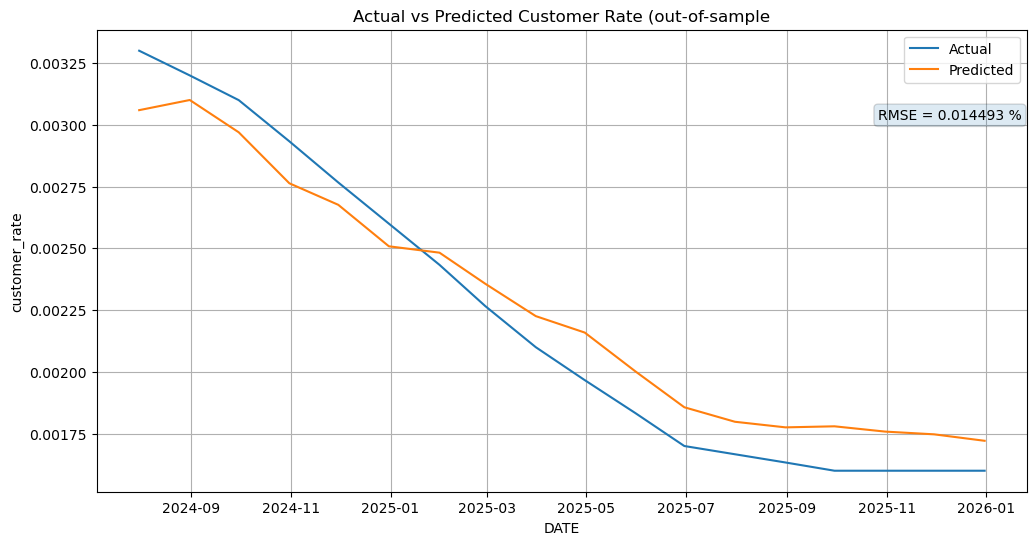

,DATE,customer_rate,customer_rate_pred_LT,forecast_error,squared_error
169,2024-07-31,0.003300,0.003059,0.000241,5.788290e-08
170,2024-08-31,0.003200,0.003101,0.000099,9.895154e-09
171,2024-09-30,0.003100,0.002970,0.000130,1.695821e-08
172,2024-10-31,0.002933,0.002763,0.000170,2.885970e-08
173,2024-11-30,0.002767,0.002676,0.000090,8.175752e-09
174,2024-12-31,0.002600,0.002508,0.000092,8.396059e-09
175,2025-01-31,0.002433,0.002483,-0.000049,2.424699e-09
176,2025-02-28,0.002267,0.002357,-0.000090,8.157907e-09
177,2025-03-31,0.002100,0.002226,-0.000126,1.581661e-08
178,2025-04-30,0.001967,0.002159,-0.000193,3.707291e-08


In [35]:
# -----------------------------
# Out-of-sample prediction
# -----------------------------

target_col = "customer_rate"

test_oos = test_table.copy()

# Add constant if the final model used it
if "cons" in final_model_long.params.index and "cons" not in test_oos.columns:
    test_oos["cons"] = 1


# Use exactly the regressors from the final estimated model
oos_regressors = final_model_long.params.index.tolist()

# Keep only valid rows
required_cols = oos_regressors + [target_col]

test_oos = (
    test_oos
    .dropna(subset=required_cols)
    .copy()
)

X_test = test_oos[oos_regressors]

# LT predicted customer_rate
test_oos["customer_rate_pred_LT"] = final_model_long.predict(X_test)

# Forecast error
test_oos["forecast_error"] = (
    test_oos["customer_rate"] - test_oos["customer_rate_pred_LT"]
)

# Squared error
test_oos["squared_error"] = test_oos["forecast_error"] ** 2

# RMSE
rmse = np.sqrt(test_oos["squared_error"].mean())

print(f"Out-of-sample RMSE = {rmse:.8f}")
print(f"Out-of-sample RMSE in percentage points = {rmse * 100:.8f}")


plt.figure(figsize=(12, 6))
plt.plot(test_oos["DATE"], test_oos["customer_rate"], label="Actual")
plt.plot(test_oos["DATE"], test_oos["customer_rate_pred_LT"], label="Predicted")
plt.xlabel("DATE")
plt.ylabel("customer_rate")
plt.title("Actual vs Predicted Customer Rate (out-of-sample")
plt.text(
    0.84,
    0.83,
    f"RMSE = {rmse*100:.6f} %",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.legend()
plt.grid(True)
plt.show()


display(
    test_oos[
        [
            "DATE",
            "customer_rate",
            "customer_rate_pred_LT",
            "forecast_error",
            "squared_error"
        ]
    ]
)

## Out of Sample fit - ECM model

$$ \begin{cases}
r_t = \alpha +\beta r_t^{m} + \sum_k \phi_k \delta_{k,t} + \varepsilon_t & \textrm{(long relationship)}\\
\Delta r_t = \theta (r_{t-1} - \hat{r}_{t-1}) + \gamma \Delta r_t^{m} & \textrm{(short relationship)}
\end{cases}$$

Combining long and short term models, the final expression of the customer rate $r_t$ is*:
$$ \Rightarrow 
r_t = r_{t-1} (1+\theta) -\theta (\alpha +\beta r_{t-1}^{m} + \sum_k \phi_k \delta_{k,t-1})
+ \gamma \Delta r_t^{m}
$$
*this expression is specifically derived for the input "test_size = 18"; in case user selects a different test_size, and the models are different (for example, short term model includes "gamma_negative" and not "gamma") the equation must be adjusted accordingly

In [36]:
final_model_long.params

Euribor_1M    0.058878
Spread        0.053358
dCovid       -0.000503
cons          0.000198
dtype: float64

In [37]:
final_model_short.params

theta   -0.020771
gamma    0.044605
dtype: float64

In [38]:
#retrieve the relevant variables
ECM_oos = input_table[["DATE","customer_rate","Euribor_1M", "Spread", "dCovid"]].copy()

alfa = to_scalar(final_model_long.params["cons"])
spread_coeff = to_scalar(final_model_long.params["Spread"])
covid_coeff = to_scalar(final_model_long.params["dCovid"]) #disable this if covid coefficient is not in long term model
#gamma_negative = to_scalar(final_model_short.params["gamma_negative"])  #disable this if gamma_negative is not in short term model

In [39]:
# variables to lag: all columns except DATE
vars_to_lag = [col for col in ECM_oos.columns if col != "DATE"]

# create lagged variables: t-1 values
for col in vars_to_lag:
    ECM_oos[f"{col}_lag1"] = ECM_oos[col].shift(1)

# delta order 1 for market rate
ECM_oos["delta1_Euribor_1M"] = ECM_oos["Euribor_1M"].diff()

# out-of-sample data slicing  
ECM_oos = ECM_oos.tail(test_size)

if "cons" in final_model_long.params.index and "cons" not in ECM_oos.columns:
    ECM_oos["cons"] = 1



In [40]:
ECM_oos

,DATE,customer_rate,Euribor_1M,Spread,dCovid,customer_rate_lag1,Euribor_1M_lag1,Spread_lag1,dCovid_lag1,delta1_Euribor_1M,cons
169,2024-07-31,0.003300,0.036175,0.0137,0,0.003400,0.036347,0.0146,0.0,-0.000172,1
170,2024-08-31,0.003200,0.035967,0.0147,0,0.003300,0.036175,0.0137,0.0,-0.000208,1
171,2024-09-30,0.003100,0.034381,0.0140,0,0.003200,0.035967,0.0147,0.0,-0.001586,1
172,2024-10-31,0.002933,0.032055,0.0127,0,0.003100,0.034381,0.0140,0.0,-0.002326,1
173,2024-11-30,0.002767,0.030664,0.0126,0,0.002933,0.032055,0.0127,0.0,-0.001390,1
174,2024-12-31,0.002600,0.028900,0.0114,0,0.002767,0.030664,0.0126,0.0,-0.001764,1
175,2025-01-31,0.002433,0.027919,0.0120,0,0.002600,0.028900,0.0114,0.0,-0.000982,1
176,2025-02-28,0.002267,0.026058,0.0117,0,0.002433,0.027919,0.0120,0.0,-0.001861,1
177,2025-03-31,0.002100,0.024010,0.0115,0,0.002267,0.026058,0.0117,0.0,-0.002048,1
178,2025-04-30,0.001967,0.022426,0.0120,0,0.002100,0.024010,0.0115,0.0,-0.001583,1


In [41]:
ECM_oos["customer_rate_predicted_ECM"] = 0

ECM_oos["customer_rate_predicted_ECM"] = (( 
    ECM_oos["customer_rate_lag1"] * (1+theta) - 
    theta * (
        alfa + 
        beta * ECM_oos["Euribor_1M_lag1"] +
        spread_coeff * ECM_oos["Spread_lag1"] +
        covid_coeff * ECM_oos["dCovid_lag1"]) #disable this if covid dummy is not in long term model
    ) + gamma * ECM_oos["delta1_Euribor_1M"]) #if short term contains "gamma"
#+ gamma_negative * np.minimum(ECM_oos["delta1_Euribor_1M"],0) # if short term contains "gamma_negative"

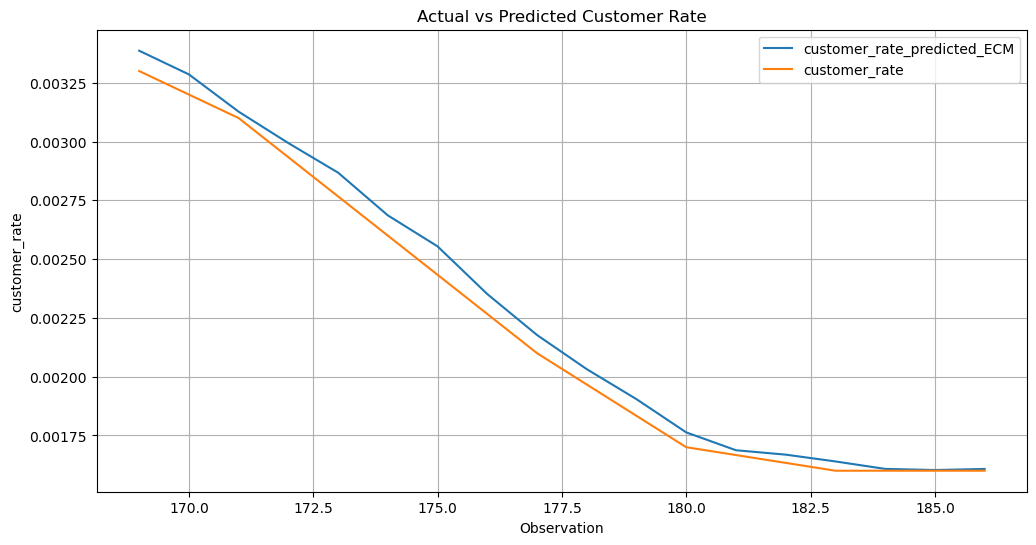

In [42]:
ECM_oos[["customer_rate_predicted_ECM","customer_rate"]].plot(
    kind="line",
    figsize=(12, 6),
    title="Actual vs Predicted Customer Rate"
)
plt.xlabel("Observation")
plt.ylabel("customer_rate")
plt.grid(True)
plt.show()

In [43]:
# Forecast error
ECM_oos["forecast_error"] = (
    ECM_oos["customer_rate"] - ECM_oos["customer_rate_predicted_ECM"]
)

# Squared error
ECM_oos["squared_error"] = ECM_oos["forecast_error"] ** 2

# RMSE
rmse_ECM = np.sqrt(ECM_oos["squared_error"].mean())

print(f"Out-of-sample RMSE = {rmse_ECM:.8f}")
print(f"Out-of-sample RMSE in percentage points = {rmse_ECM * 100:.8f}")

Out-of-sample RMSE = 0.00006717
Out-of-sample RMSE in percentage points = 0.00671684


In [44]:
ECM_oos

,DATE,customer_rate,Euribor_1M,Spread,dCovid,customer_rate_lag1,Euribor_1M_lag1,Spread_lag1,dCovid_lag1,delta1_Euribor_1M,cons,customer_rate_predicted_ECM,forecast_error,squared_error
169,2024-07-31,0.003300,0.036175,0.0137,0,0.003400,0.036347,0.0146,0.0,-0.000172,1,0.003386,-0.000086,7.477193e-09
170,2024-08-31,0.003200,0.035967,0.0147,0,0.003300,0.036175,0.0137,0.0,-0.000208,1,0.003286,-0.000086,7.349180e-09
171,2024-09-30,0.003100,0.034381,0.0140,0,0.003200,0.035967,0.0147,0.0,-0.001586,1,0.003127,-0.000027,7.385248e-10
172,2024-10-31,0.002933,0.032055,0.0127,0,0.003100,0.034381,0.0140,0.0,-0.002326,1,0.002994,-0.000060,3.624376e-09
173,2024-11-30,0.002767,0.030664,0.0126,0,0.002933,0.032055,0.0127,0.0,-0.001390,1,0.002868,-0.000101,1.022420e-08
174,2024-12-31,0.002600,0.028900,0.0114,0,0.002767,0.030664,0.0126,0.0,-0.001764,1,0.002686,-0.000086,7.415743e-09
175,2025-01-31,0.002433,0.027919,0.0120,0,0.002600,0.028900,0.0114,0.0,-0.000982,1,0.002554,-0.000121,1.463308e-08
176,2025-02-28,0.002267,0.026058,0.0117,0,0.002433,0.027919,0.0120,0.0,-0.001861,1,0.002351,-0.000085,7.169569e-09
177,2025-03-31,0.002100,0.024010,0.0115,0,0.002267,0.026058,0.0117,0.0,-0.002048,1,0.002177,-0.000077,5.961971e-09
178,2025-04-30,0.001967,0.022426,0.0120,0,0.002100,0.024010,0.0115,0.0,-0.001583,1,0.002032,-0.000065,4.265842e-09


In [45]:
ECM_oos = ECM_oos.join(test_oos[["customer_rate_pred_LT"]])

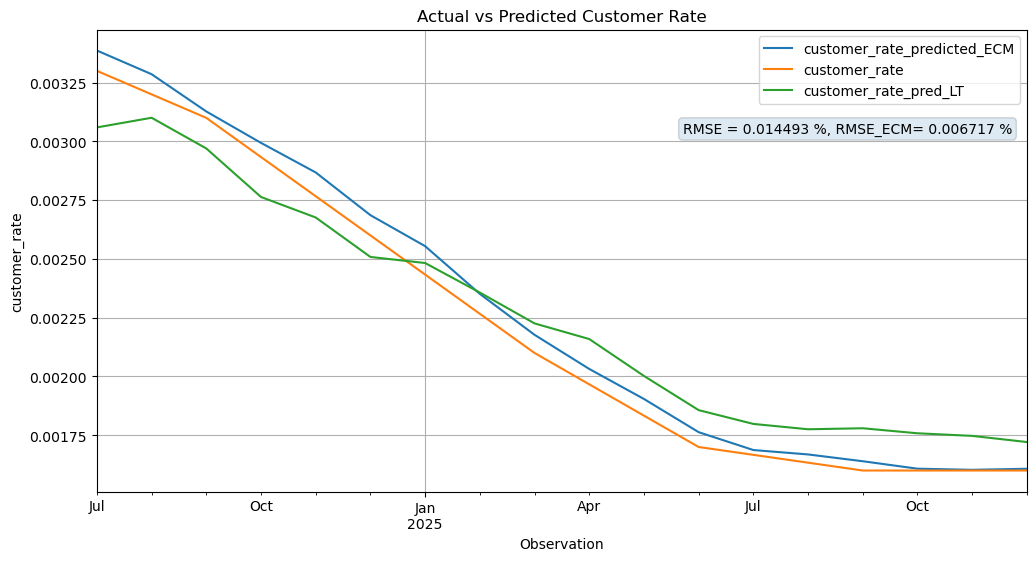

In [46]:
ECM_oos[["customer_rate_predicted_ECM","customer_rate", "customer_rate_pred_LT", "DATE"]].plot(
    x = "DATE",
    y = ["customer_rate_predicted_ECM","customer_rate", "customer_rate_pred_LT"],
    kind="line",
    figsize=(12, 6),
    title="Actual vs Predicted Customer Rate"
)
plt.xlabel("Observation")
plt.ylabel("customer_rate")
plt.grid(True)
plt.text(
    0.63,
    0.80,
    f"RMSE = {rmse*100:.6f} %, RMSE_ECM= {rmse_ECM*100:.6f} %",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.show()